In [83]:
# installing the scraper (google-play reviews)

from google_play_scraper import reviews, Sort
import pandas as pd

# Scrape Revolut reviews
result, _ = reviews(
    'com.revolut.revolut',  # Revolut's app ID
    lang='en',
    country='us',
    sort=Sort.NEWEST,
    count=5000  # Get 5000 reviews
)

# Converting to dataframe
df = pd.DataFrame(result)
print(df.shape)
print(df.columns.tolist())
print(df.head())

# Save to CSV
df.to_csv('revolut_reviews.csv', index=False)
print("Saved successfully!")

(5000, 11)
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']
                               reviewId       userName  \
0  667c32e9-fb6e-4cdd-ae66-aa5c3b2652a0  A Google user   
1  bc5ab8e0-bb12-44ab-b0bd-b37bea7fd38e  A Google user   
2  31571a02-5bca-43c2-b0aa-e0a60584af63  A Google user   
3  7c2437de-58ab-4846-9e31-9ee3d50b301b  A Google user   
4  572ced25-7b93-4fd8-86a2-afa72cf296e8  A Google user   

                                           userImage  \
0  https://play-lh.googleusercontent.com/EGemoI2N...   
1  https://play-lh.googleusercontent.com/EGemoI2N...   
2  https://play-lh.googleusercontent.com/EGemoI2N...   
3  https://play-lh.googleusercontent.com/EGemoI2N...   
4  https://play-lh.googleusercontent.com/EGemoI2N...   

                                             content  score  thumbsUpCount  \
0                                               good      5              0   

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# rating the distribution of 1 star to 5 stars reviews
print("=== RATING DISTRIBUTION ===")
print(df['score'].value_counts().sort_index())

# Checking missing values
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# Checking date range
print("\n=== DATE RANGE ===")
print("Earliest review:", df['at'].min())
print("Latest review:", df['at'].max())

=== RATING DISTRIBUTION ===
score
1     438
2      56
3      77
4     341
5    4088
Name: count, dtype: int64

=== MISSING VALUES ===
reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion     876
at                         0
replyContent            4501
repliedAt               4501
appVersion               876
dtype: int64

=== DATE RANGE ===
Earliest review: 2026-02-12 13:04:54
Latest review: 2026-03-28 15:28:02


C:\Users\vaikh\AppData\Local\Temp\ipykernel_31044\4139520157.py:20: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vaikh\AppData\Local\Temp\ipykernel_31044\4139520157.py:21: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
C:\Users\vaikh\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


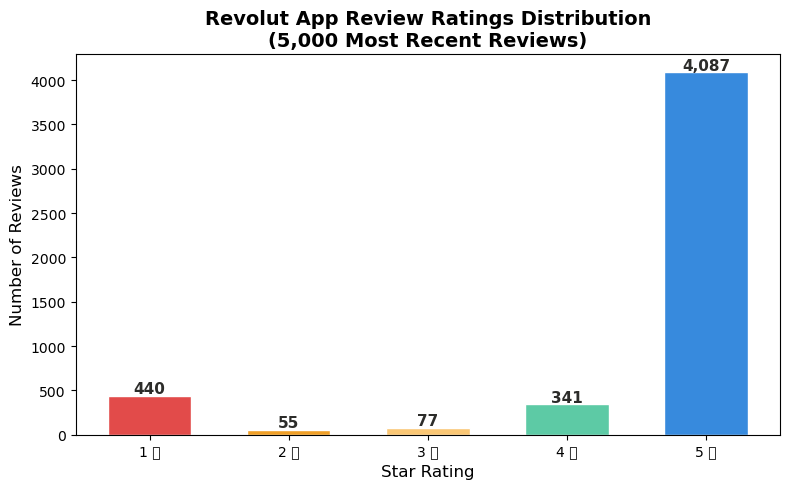

In [43]:
# Rating distribution bar chart
plt.figure(figsize=(8, 5))
colors = ['#E24B4A', '#EF9F27', '#FAC775', '#5DCAA5', '#378ADD']
bars = plt.bar(df['score'].value_counts().sort_index().index,
               df['score'].value_counts().sort_index().values,
               color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, df['score'].value_counts().sort_index().values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30,
             f'{val:,}', ha='center', fontsize=11,
             fontweight='bold', color='#2C2C2A')

plt.title('Revolut App Review Ratings Distribution\n(5,000 Most Recent Reviews)',
          fontsize=14, fontweight='bold')
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks([1, 2, 3, 4, 5],
           ['1 ⭐', '2 ⭐', '3 ⭐', '4 ⭐', '5 ⭐'])
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [85]:
## code used to install the pre-trained models from hugging face
import sys
!{sys.executable} -m pip install transformers torch


In [86]:
## Loading the model

from transformers import pipeline

# Load pre-trained sentiment analysis model
print("Loading AI model... this may take a minute!")
sentiment_model = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    truncation=True,
    max_length=512
)
print("Model loaded successfully!")


Loading AI model... this may take a minute!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [87]:
# Run sentiment analysis on all reviews
print("Analysing 5,000 reviews... please wait!")

# clean reviews
df_clean = df[df['content'].str.len() > 10].copy()
print(f"Reviews to analyse: {len(df_clean)}")

# Run AI model in batches
from tqdm import tqdm  ## tqdm to know the progress
results = []

for review in tqdm(df_clean['content'].tolist()):
    try:
        result = sentiment_model(review[:512])
        results.append(result[0]['label'])
    except:
        results.append('neutral')

# Add results to dataframe
df_clean['sentiment'] = results

print("\n=== SENTIMENT DISTRIBUTION ===")
print(df_clean['sentiment'].value_counts())

Analysing 5,000 reviews... please wait!
Reviews to analyse: 3746


100%|██████████| 3746/3746 [03:41<00:00, 16.91it/s]


=== SENTIMENT DISTRIBUTION ===
sentiment
positive    2836
negative     548
neutral      362
Name: count, dtype: int64


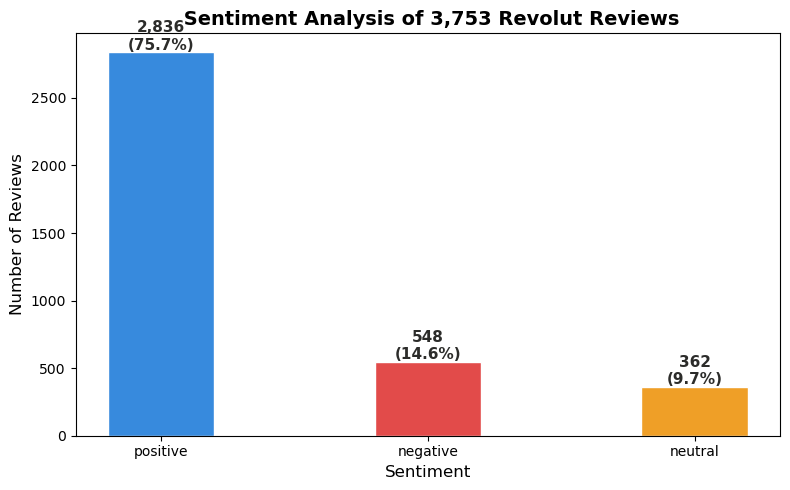

In [89]:
# Sentiment distribution chart
sentiment_counts = df_clean['sentiment'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#378ADD', '#E24B4A', '#EF9F27']
bars = plt.bar(sentiment_counts.index,
               sentiment_counts.values,
               color=colors, width=0.4, edgecolor='white')

for bar, val in zip(bars, sentiment_counts.values):
    pct = val / len(df_clean) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', fontsize=11,
             fontweight='bold', color='#2C2C2A')

plt.title(' Sentiment Analysis of 3,753 Revolut Reviews',
          fontsize=14, fontweight='bold')
plt.ylabel('Number of Reviews', fontsize=12)
plt.xlabel('Sentiment', fontsize=12)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [90]:
# Separate negative reviews
negative_reviews = df_clean[df_clean['sentiment'] == 'negative']['content']

print(f"Total negative reviews: {len(negative_reviews)}")
print("\n=== SAMPLE NEGATIVE REVIEWS ===")
for i, review in enumerate(negative_reviews.head(10)):
    print(f"\n{i+1}. {review}")
    print("-" * 50)

Total negative reviews: 548

=== SAMPLE NEGATIVE REVIEWS ===

1. the worst part is that they are not trying to help you with refunds or when you have problem with purchases that the merchant don't communicate with you or there is no info. happened at least 3 times so far with no small amounts (30-70 euros) and revolut just didn't want to try resolve the issue
--------------------------------------------------

2. sham of a company, locked my account and then said they were closing it. Stick with Monzo they know what they are doing.
--------------------------------------------------

3. Very bad web / computer support
--------------------------------------------------

4. They are financial theifs. Since I have joined they are deducting money and not letting me to close account and fund transfer. plesse avoid using them.
--------------------------------------------------

5. is a big scam they said if you invite your friend you will get from £10 to £200 each what is a scam they will giv

In [96]:
def categorize_review(text):
    text = text.lower()
    
    # Account & Access Issues
    if any(word in text for word in ['account', 'frozen', 'blocked',
                                      'closed', 'suspended', 'login',
                                      'password', 'access', 'verify',
                                      'verification', 'code', 'log in',
                                      'scan', 'ssn', 'biometric', 'face',
                                      'passport', 'kyc', 'document',
                                      'identity', 'pending', 'sign up',
                                      'register', 'onboard']):
        return 'Account & Access Issues'
    
    # Payments & Money
    elif any(word in text for word in ['transfer', 'send', 'money',
                                        'payment', 'transaction', 'fee',
                                        'charge', 'expensive', 'cost',
                                        'price', 'card', 'physical',
                                        'delivery', 'ordered', 'arrive',
                                        'refund', 'chargeback', 'merchant',
                                        'receipt', 'dispute']):
        return 'Payments & Money'
    
    # App Performance
    elif any(word in text for word in ['crash', 'bug', 'update',
                                        'reinstall', 'freeze', 'memory',
                                        'fix', 'broken', 'open', 'fail',
                                        'fails', 'compatible', 'device',
                                        'working', 'notification', 'ux',
                                        'design', 'confusing', 'interface',
                                        'navigate', 'settings', 'layout',
                                        'intuitive', 'gui', 'confused',
                                        'canada', 'country', 'available',
                                        'region', 'supported']):
        return 'App Performance'
    
    # Customer Support
    elif any(word in text for word in ['support', 'service', 'help',
                                        'response', 'chat', 'contact',
                                        'agent', 'chatbot', 'bot',
                                        'nonsense', 'ombudsman']):
        return 'Customer Support'
    
    # Security & Trust
    elif any(word in text for word in ['scam', 'fraud', 'stolen',
                                        'fake', 'cheat', 'hostile',
                                        'privacy', 'data', 'gdpr',
                                        'security', 'refugee']):
        return 'Security & Trust'
    
    # Features & Products
    elif any(word in text for word in ['invest', 'investment', 'stocks',
                                        'crypto', 'bitcoin', 'btc',
                                        'cryptocurrency', 'fx', 'currency',
                                        'decimal', 'forex', 'spam',
                                        'email', 'marketing', 'feature',
                                        'referral']):
        return 'Features & Products'
    
    else:
        return 'Other'

# Apply final categorization
negative_df['category'] = negative_df['content'].apply(categorize_review)

print("=== FINAL 6 COMPLAINT CATEGORIES ===")
print(negative_df['category'].value_counts())

remaining = negative_df[negative_df['category'] == 'Other']
print(f"\nRemaining uncategorized: {len(remaining)}")

=== FINAL 6 COMPLAINT CATEGORIES ===
category
Account & Access Issues    265
Payments & Money           109
App Performance             69
Other                       55
Customer Support            28
Security & Trust            11
Features & Products         10
Name: count, dtype: int64

Remaining uncategorized: 55


C:\Users\vaikh\AppData\Local\Temp\ipykernel_31044\568809009.py:54: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vaikh\AppData\Local\Temp\ipykernel_31044\568809009.py:54: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vaikh\AppData\Local\Temp\ipykernel_31044\568809009.py:54: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vaikh\AppData\Local\Temp\ipykernel_31044\568809009.py:54: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vaikh\AppData\Local\Temp\ipykernel_31044\568809009.py:54: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vaikh\AppData\Local\Temp\ipykernel_31044\568809009.py:54: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tigh

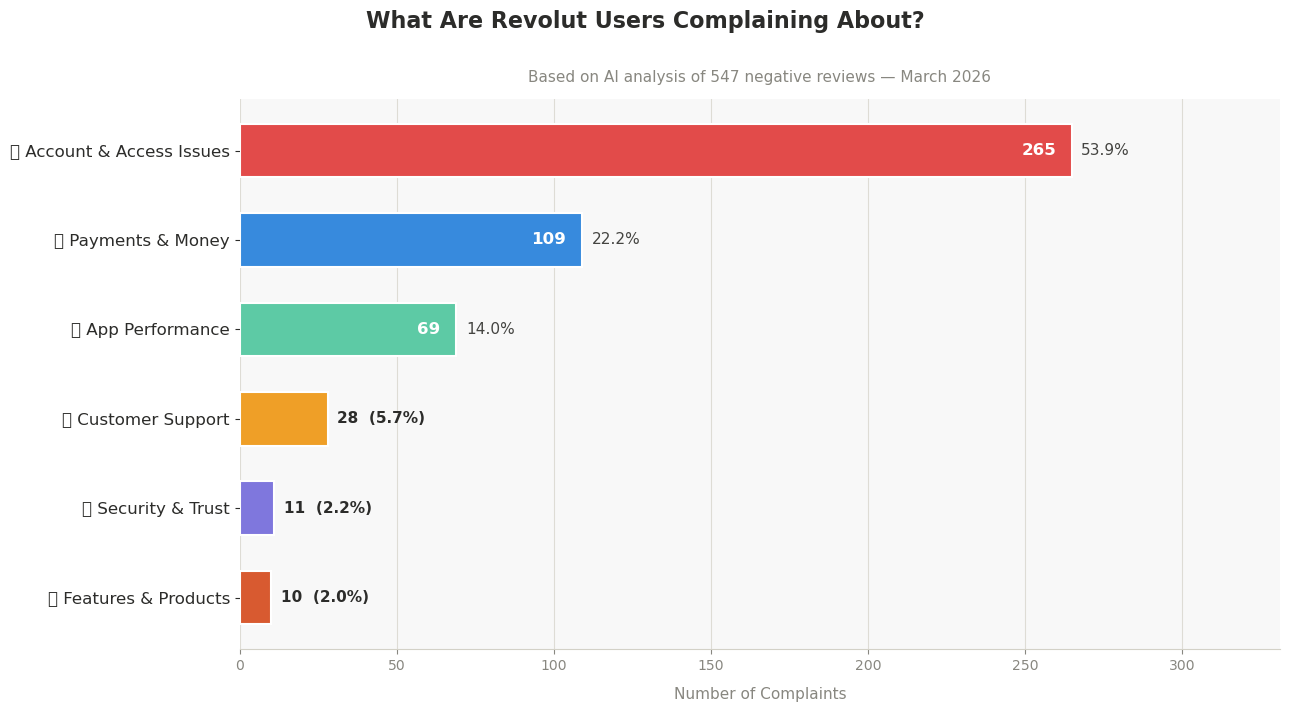

In [93]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F8F8')

categories = category_counts.index[::-1]
values = category_counts.values[::-1]

colors = ['#E24B4A', '#378ADD', '#5DCAA5',
          '#EF9F27', '#7F77DD', '#D85A30'][::-1]

bars = ax.barh(categories, values, color=colors,
               edgecolor='white', linewidth=1.5, height=0.6)

# labelling
for bar, val in zip(bars, values):
    pct = val / sum(values) * 100
    bar_width = bar.get_width()
    
    if bar_width > 40:  # wide enough — label inside
        ax.text(bar_width - 5,
                bar.get_y() + bar.get_height()/2,
                f'{val}',
                va='center', ha='right',
                fontsize=12, fontweight='bold', color='white')
        ax.text(bar_width + 3,
                bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%',
                va='center', ha='left',
                fontsize=11, color='#444441')
    else:  # too small — both labels outside
        ax.text(bar_width + 3,
                bar.get_y() + bar.get_height()/2,
                f'{val}  ({pct:.1f}%)',
                va='center', ha='left',
                fontsize=11, fontweight='bold', color='#2C2C2A')

# Style
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#D3D1C7')
ax.tick_params(axis='y', labelsize=12, colors='#2C2C2A')
ax.tick_params(axis='x', colors='#888780')
ax.set_xlabel('Number of Complaints', fontsize=11,
               color='#888780', labelpad=10)
ax.set_xlim(0, max(values) * 1.25)
ax.xaxis.grid(True, color='#D3D1C7', linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)

fig.suptitle('What Are Revolut Users Complaining About?',
             fontsize=16, fontweight='bold',
             color='#2C2C2A', y=1.01)
ax.set_title('Based on AI analysis of 547 negative reviews — March 2026',
             fontsize=11, color='#888780', pad=12)

plt.tight_layout()
plt.savefig('complaint_categories.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

In [99]:
for category in ['Account & Access Issues', 'Payments & Money', 
                 'App Performance', 'Customer Support',
                 'Security & Trust', 'Features & Products']:
    cat_reviews = negative_df[negative_df['category'] == category]
    top_reviews = cat_reviews.nlargest(3, 'thumbsUpCount')[
        ['content', 'thumbsUpCount']]
    
    print(f"\n{category} ({len(cat_reviews)} complaints)")
    print("=" * 60)
    for _, row in top_reviews.iterrows():
        print(f"{row['thumbsUpCount']} likes — {row['content'][:150]}...")
        print()


Account & Access Issues (265 complaints)
41 likes — The most important function on this app is the hardest thing to do: transferring money. You can't just enter an amount, name and bank account number a...

18 likes — Several times account locked, useless support, no yearly trading statement. their transaction claim service is completly useless. Their business model...

14 likes — I have tried to log into my app numerous times. I have all the correct passwords, but cannot get in. I have uninstalled and reinstalled and still cann...


Payments & Money (109 complaints)
52 likes — can't block anything in this app anymore - from one payment purchases I don't want to risc in the future to stuff like Netflix and Google Pay. One of ...

46 likes — How many more years do you need to finalise my cases??? Despite sending all necessary information, Revolut ignored and not keen to review all details ...

32 likes — Awful. used to be great but now although security is of course important, trying t

In [82]:
def analyze_new_review(review_text):
    
    #  AI Sentiment
    sentiment_result = sentiment_model(review_text[:512])
    sentiment = sentiment_result[0]['label']
    confidence = sentiment_result[0]['score']
    
    #  Categorizing
    category = categorize_review(review_text)
    
    # Prioritizing based on category
    priority_map = {
        '🔴 Account & Access Issues': 'P1 — Critical',
        '💸 Payments & Money':        'P2 — High',
        '📱 App Performance':         'P3 — Medium',
        '🎧 Customer Support':        'P2 — High',
        '🔒 Security & Trust':        'P1 — Critical',
        '📈 Features & Products':     'P3 — Medium',
        'Other':                      'P4 — Low'
    }
    priority = priority_map.get(category, 'P4 — Low')
    
    # Recommendation
    recommendations = {
        '🔴 Account & Access Issues': 'Escalate to account recovery team',
        '💸 Payments & Money':        'Review payment flow and dispute process',
        '📱 App Performance':         'Flag to engineering team for bug fix',
        '🎧 Customer Support':        'Review support ticket and response time',
        '🔒 Security & Trust':        'Escalate to security and fraud team',
        '📈 Features & Products':     'Add to product backlog for next sprint',
        'Other':                      'Manual review required'
    }
    recommendation = recommendations.get(category, 'Manual review required')
    
    # Print results
    print("=" * 60)
    print(f"📝 REVIEW: {review_text[:100]}...")
    print(f"💬 SENTIMENT:      {sentiment} ({confidence*100:.1f}% confidence)")
    print(f"📂 CATEGORY:       {category}")
    print(f"🚨 PRIORITY:       {priority}")
    print(f"✅ RECOMMENDATION: {recommendation}")
    print("=" * 60)

# Test with 3 new reviews
analyze_new_review("My account got frozen and I can't access my money for 10 days")
analyze_new_review("The app keeps crashing every time I open the stocks page")
analyze_new_review("Waited 9 hours for customer support to reply. Absolutely unacceptable")

📝 REVIEW: My account got frozen and I can't access my money for 10 days...
💬 SENTIMENT:      negative (88.0% confidence)
📂 CATEGORY:       Account & Access Issues
🚨 PRIORITY:       P4 — Low
✅ RECOMMENDATION: Manual review required
📝 REVIEW: The app keeps crashing every time I open the stocks page...
💬 SENTIMENT:      negative (80.3% confidence)
📂 CATEGORY:        App Performance
🚨 PRIORITY:       P4 — Low
✅ RECOMMENDATION: Manual review required
📝 REVIEW: Waited 9 hours for customer support to reply. Absolutely unacceptable...
💬 SENTIMENT:      negative (93.6% confidence)
📂 CATEGORY:        Customer Support
🚨 PRIORITY:       P4 — Low
✅ RECOMMENDATION: Manual review required


In [74]:
# Test with 5 different reviews
test_reviews = [
    "My account has been frozen for 2 weeks and I cant access my money",
    "The app keeps crashing every time I open it on my Samsung phone",
    "Transfer failed 3 times and I was charged fees each time",
    "Customer support took 12 hours to reply and gave me wrong information",
    "I love this app it is so easy to use and transfers are instant"
]

for review in test_reviews:
    analyze_new_review(review)
    print()

📝 REVIEW: My account has been frozen for 2 weeks and I cant access my money...
💬 SENTIMENT:      negative (88.7% confidence)
📂 CATEGORY:       🔴 Account & Access Issues
🚨 PRIORITY:       P1 — Critical
✅ RECOMMENDATION: Escalate to account recovery team

📝 REVIEW: The app keeps crashing every time I open it on my Samsung phone...
💬 SENTIMENT:      negative (73.8% confidence)
📂 CATEGORY:       📱 App Performance
🚨 PRIORITY:       P3 — Medium
✅ RECOMMENDATION: Flag to engineering team for bug fix

📝 REVIEW: Transfer failed 3 times and I was charged fees each time...
💬 SENTIMENT:      negative (85.0% confidence)
📂 CATEGORY:       💸 Payments & Money
🚨 PRIORITY:       P2 — High
✅ RECOMMENDATION: Review payment flow and dispute process

📝 REVIEW: Customer support took 12 hours to reply and gave me wrong information...
💬 SENTIMENT:      negative (88.7% confidence)
📂 CATEGORY:       🎧 Customer Support
🚨 PRIORITY:       P2 — High
✅ RECOMMENDATION: Review support ticket and response time

📝 REVIEW